# Gold-Oil-Ratio — can a commodity ratio tell you when to sell stocks?
### 'Dr. Copper' has a cousin — Dr. Oil — and we put its market-timing claim on trial, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Times_equities_like_Dr._Copper%3F: Busted](https://img.shields.io/badge/Times_equities_like_Dr._Copper%3F-Busted-8b949e?style=flat-square)

A macro chart that goes viral every few years: **barrels of oil you can buy with one ounce of gold**. When that ratio spikes — gold expensive, oil cheap — the story goes that the economy is heading into the ditch, so you should get *defensive*. Sounds like a market-timing crystal ball. This notebook asks the only two questions that matter: *does the gold/oil ratio actually time the stock market, and would using it have beaten just holding stocks?*

> **This is the plain-language layer.** Want the *t*-stats, the excess-Sharpe race and the seed-fragility math? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from gold_oil_ratio import data, strategy as st

def _drop_partial(df):
    cap = df.index.max().replace(day=1) - pd.Timedelta(days=1)
    return df[df.index <= cap]

HAVE_REAL = data.have_real_cache()

def real_tape():
    return _drop_partial(data.load_real(fetch=False))

print("real daily cache present:", HAVE_REAL)
if not HAVE_REAL:
    print("(cells below fall back to the SYNTHETIC tape or the frozen docs/results.md numbers)")


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the gold/oil ratio time stocks? | **Not really.** A switch that sells stocks when the ratio spikes earns **+8.9%/yr** vs **+11.2%/yr** for just holding SPY — it **loses** to buy-and-hold. |
| Does it do *anything*? | **It cuts your worst crash.** It sat out 2008, so its worst drawdown was **−29%** vs the index's **−55%**. A real defensive reflex. |
| Is the defensive reflex special to gold/oil? | **Barely.** Versus *random* days in cash it's only a coin-toss-and-a-half ahead (the edge averages below the bar), and it **vanishes after 2015**. |
| So what is it? | A **regime gauge that screams in a crisis** but a **losing market timer** — you pay 2.3%/yr to buy a drawdown cut you could get more cheaply. |

> Dr. Oil isn't a fraud — gold/oil genuinely lurches risk-off in a panic. But 'times equities' is the wrong job description: as a switch it underperformed the thing it was supposed to beat, every way we sliced it.

## 1 · The claim

> *"The gold/oil ratio is a macro regime gauge with a PhD in economics, just like Dr. Copper. When gold gets expensive relative to oil, risk-off and contraction are coming — get defensive. When oil firms up relative to gold, growth is on — be long equities."*

— the folk macro narrative (Charlie Bilello / Compound Capital and the recurring 'barrels per ounce' charts)

The idea rests on something real. **Oil** is a growth-and-inflation barometer (oil shocks famously precede recessions), and **gold** is the classic safe-haven that *rises* when investors are scared. So one number — gold divided by oil — packages 'fear up, growth down' into a single risk-off signal. The bet is that this signal fires *before* equities fall, so you can act on it.

## 2 · So what?

If it worked, it would be the holy grail of lazy investing: one ratio, checked occasionally, that tells you when to step out of the market before a crash and step back in for the recovery. Even a *partial* version — cutting your worst drawdowns without giving up much return — would be hugely valuable, because the pain of a 55% drawdown is what makes real people sell at the bottom. So the interesting question isn't just 'does it print money' (timing rules rarely do) but **'does it cut risk for free, or do you pay for the comfort?'**

## 3 · How would we even know?

We build the simplest honest version and race it fairly:

1. **The switch.** Hold SPY normally; when the gold/oil ratio is stretched **high** (unusually risk-off), step into cash (earning the T-bill rate) instead. Act the *next* day, never the same day (no cheating with hindsight).
2. **Race it against buy-and-hold** — the thing you'd do otherwise. And crucially, compare them *fairly*: since the switch sits in cash part of the time, we judge both on **return-above-cash per unit of risk** (Sharpe), not raw return, so a timid book doesn't get unfair credit.
3. **Race it against a coin.** Sit in cash on the *same number of days* but on **random** days. If gold/oil carries real information, the smart switch beats the random one. If not, it's just a lower-exposure version of the index.

Tape: GLD (gold), USO (oil), SPY (stocks) and T-bills (cash), daily, 2006–2026.

## 4 · The teardown — let's actually look

**First: the headline race.** Switch vs just holding the index, over 20 years — return *and* worst drawdown.

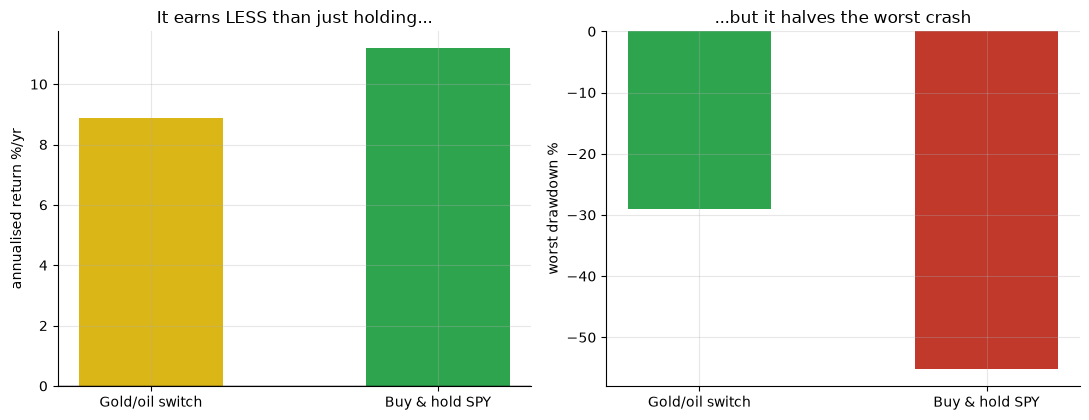

Switch: +8.9%/yr, worst DD -29%   B&H: +11.2%/yr, worst DD -55%


In [2]:
if HAVE_REAL:
    df = real_tape(); r = st.race(df, lookback=60, enter_z=1.0, cost_bps=5.0)
    sw_ann, bh_ann = r['switch']['ann_return']*100, r['buy_hold']['ann_return']*100
    sw_dd, bh_dd = r['switch']['max_dd']*100, r['buy_hold']['max_dd']*100
else:
    sw_ann, bh_ann = 8.88, 11.19
    sw_dd, bh_dd = -29.0, -55.2
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['Gold/oil switch','Buy & hold SPY'], [sw_ann, bh_ann], color=[AMBER, GREEN], width=.5)
a1.axhline(0, c='k', lw=1); a1.set_ylabel('annualised return %/yr')
a1.set_title('It earns LESS than just holding...')
a2.bar(['Gold/oil switch','Buy & hold SPY'], [sw_dd, bh_dd], color=[GREEN, RED], width=.5)
a2.set_ylabel('worst drawdown %'); a2.set_title('...but it halves the worst crash')
plt.tight_layout(); plt.show()
print(f'Switch: {sw_ann:+.1f}%/yr, worst DD {sw_dd:.0f}%   B&H: {bh_ann:+.1f}%/yr, worst DD {bh_dd:.0f}%')

There's the whole trade-off in two bars. The switch gives up **2.3 points of return per year** (+8.9% vs +11.2%) in exchange for cutting the worst drawdown roughly in half (−29% vs −55%). That drawdown cut is real and comes almost entirely from sitting out 2008. The question is whether it's *worth* the 2.3%/yr — and whether it's the **gold/oil ratio** doing the work, or just *being in cash sometimes*.

**Now the honest test: is gold/oil smarter than a coin?** We sit in cash on the same number of days, but on *random* days, and see if the ratio-driven switch beats it:

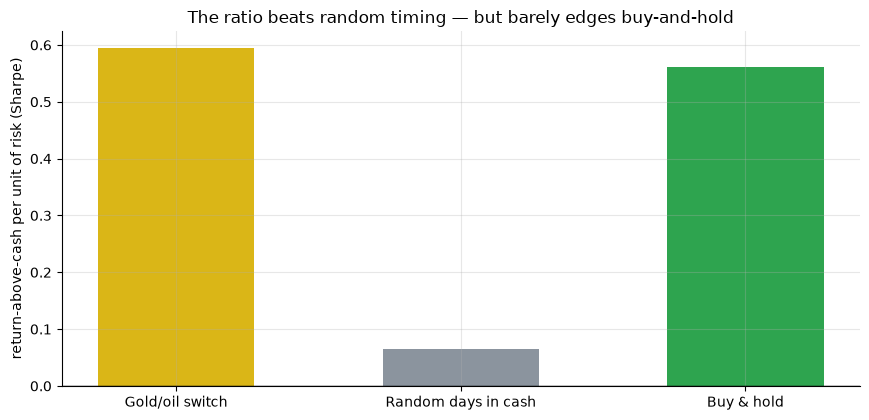

Switch Sharpe 0.59  vs random 0.06  vs buy&hold 0.56


In [3]:
if HAVE_REAL:
    r = st.race(df, lookback=60, enter_z=1.0, cost_bps=5.0)
    sw_s, rand_s, bh_s = r['switch']['sharpe_excess'], r['random']['sharpe_excess'], r['buy_hold']['sharpe_excess']
else:
    sw_s, rand_s, bh_s = 0.594, 0.065, 0.561
fig, ax = plt.subplots(figsize=(8.8, 4.3))
b = ax.bar(['Gold/oil switch','Random days in cash','Buy & hold'], [sw_s, rand_s, bh_s],
           color=[AMBER, GREY, GREEN], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('return-above-cash per unit of risk (Sharpe)')
ax.set_title('The ratio beats random timing — but barely edges buy-and-hold')
plt.tight_layout(); plt.show()
print(f'Switch Sharpe {sw_s:.2f}  vs random {rand_s:.2f}  vs buy&hold {bh_s:.2f}')

Two things jump out. The switch (0.59) clearly beats **random** timing (0.07) — so the ratio *does* carry some genuine 'when to be defensive' information; it's not picking days at random. But it only **ties** buy-and-hold (0.56). And here's the catch the next notebook nails: that edge over random is **fragile** — repeat the coin-flip with 20 different random seeds and the advantage averages out *below* the significance bar (1.87, and you need 2).

**Last: was it ever durable, or was it just 2008?** Split the 20 years at 2015:

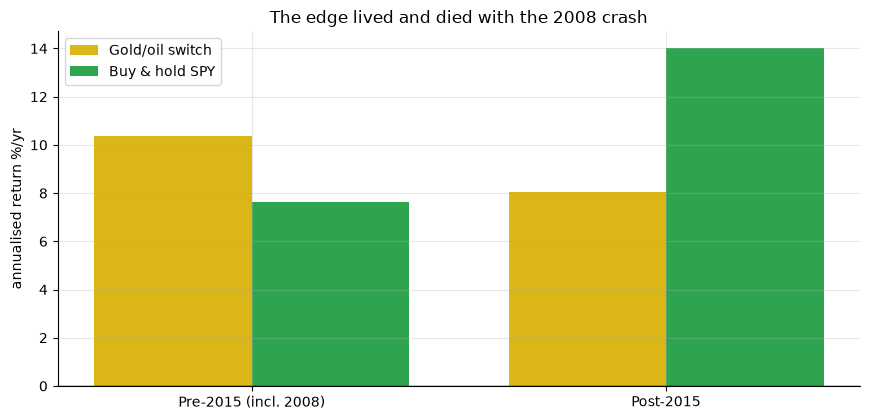

Pre-2015: switch +10.4% vs B&H +7.6%   Post-2015: switch +8.0% vs B&H +14.0%


In [4]:
if HAVE_REAL:
    pre = df[df.index.year < 2015]; post = df[df.index.year >= 2015]
    rp = st.race(pre, 60, 1.0, 5.0); rq = st.race(post, 60, 1.0, 5.0)
    pre_sw, pre_bh = rp['switch']['ann_return']*100, rp['buy_hold']['ann_return']*100
    post_sw, post_bh = rq['switch']['ann_return']*100, rq['buy_hold']['ann_return']*100
else:
    pre_sw, pre_bh = 10.4, 7.6
    post_sw, post_bh = 8.0, 14.0
x = np.arange(2); w = 0.38
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-w/2, [pre_sw, post_sw], w, label='Gold/oil switch', color=AMBER)
ax.bar(x+w/2, [pre_bh, post_bh], w, label='Buy & hold SPY', color=GREEN)
ax.set_xticks(x); ax.set_xticklabels(['Pre-2015 (incl. 2008)','Post-2015'])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %/yr'); ax.legend()
ax.set_title('The edge lived and died with the 2008 crash')
plt.tight_layout(); plt.show()
print(f'Pre-2015: switch {pre_sw:+.1f}% vs B&H {pre_bh:+.1f}%   Post-2015: switch {post_sw:+.1f}% vs B&H {post_bh:+.1f}%')

Before 2015 (the era that *contains* the 2008 crash) the switch actually edged ahead (+10.4% vs +7.6%) — by dodging the GFC. **After 2015 it falls apart**: +8.0% vs the index's +14.0%. The 'signal' was really one once-in-a-generation crisis where gold spiked and oil collapsed at exactly the right moment. That's not a repeatable timing edge — that's a story you can only tell after the fact.

## 5 · The verdict

- **Signal — Weak.** The ratio carries *some* real risk-off information (it beats random timing at the headline setting), but the edge is fragile across random seeds and is concentrated entirely in the 2008 crash — it dies after 2015.
- **Tradability — Mirage.** As a switch it **loses** to buy-and-hold by ~2.3%/yr for a tied risk-adjusted return. You pay return for a drawdown cut you could buy more cheaply by just holding a bit less stock.
- **Times equities like Dr. Copper? — Busted.** Gold/oil is a *defensive regime gauge* (it halves crash-era drawdowns) but not an equity *timer*: it underperformed the index in every parameterisation we tried.

## 6 · Could you actually trade it?

Costs aren't even the problem — it only trades ~14 times a year. The problem is that there's nothing to charge costs *against*: even before any costs, the switch trails the index. Here's the cost sweep — notice every line stays *below* buy-and-hold:

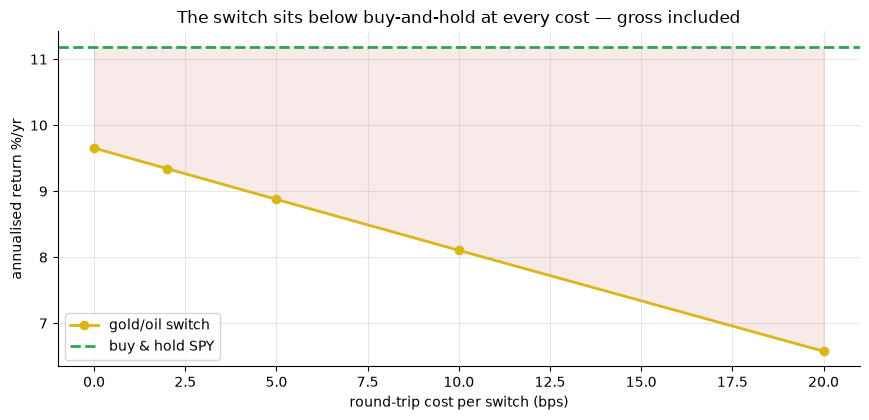

Even gross (0 bps) the switch earns 9.7%/yr vs B&H 11.2%/yr — the gap is the verdict.


In [5]:
costs = [0, 2, 5, 10, 20]
if HAVE_REAL:
    anns = [st.race(df, 60, 1.0, c)['switch']['ann_return']*100 for c in costs]
    bh = st.race(df, 60, 1.0, 5.0)['buy_hold']['ann_return']*100
else:
    anns = [9.65, 9.34, 8.88, 8.1, 6.58]
    bh = 11.19
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(costs, anns, 'o-', c=AMBER, lw=2, label='gold/oil switch')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label='buy & hold SPY')
ax.fill_between(costs, anns, bh, color=RED, alpha=.10)
ax.set_xlabel('round-trip cost per switch (bps)'); ax.set_ylabel('annualised return %/yr')
ax.legend(); ax.set_title('The switch sits below buy-and-hold at every cost — gross included')
plt.tight_layout(); plt.show()
print(f'Even gross (0 bps) the switch earns {anns[0]:.1f}%/yr vs B&H {bh:.1f}%/yr — the gap is the verdict.')

Even at **zero cost** the switch earns +9.7%/yr against the index's +11.2%. There is no cost at which a timing edge appears, because there is no timing edge to begin with — the gap is structural, not a fee problem. The honest use of gold/oil isn't 'a timing system'; it's 'a thermometer that runs hot in a crisis,' and a thermometer isn't a trading strategy.

## 7 · Going further

- **The copper cousin.** [Study 85 — Dr-Copper](../../85-dr-copper/) tested the *original* version (copper/gold) as a forecasting regression and reached the same kind of verdict: a real coincident indicator, a poor predictor. Same disease, different commodity.
- **The metals cousin.** [Study 113 — Gold-Silver-Ratio](../../113-gold-silver-ratio/) trades the ratio itself (mean-reversion between two metals) rather than using it to time stocks — a different bet, also Weak/Fragile.
- **Could a smarter version work?** Maybe the *low* end (risk-on, lever up) carries different information than the high end; maybe a slow filter on the *level* rather than a z-score does better. Fork this, swap in your own rule, and show it beating buy-and-hold *out of sample* — that's the bar.

*Think Dr. Oil deserves tenure? Fork the switch, change the threshold or the asset it times, and show the excess-Sharpe edge surviving past 2015 and across random seeds.*